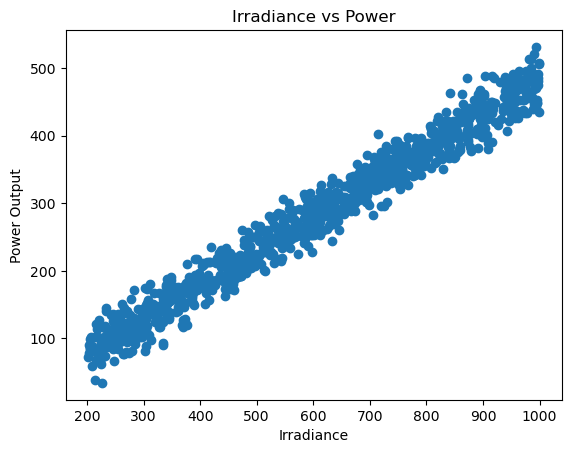

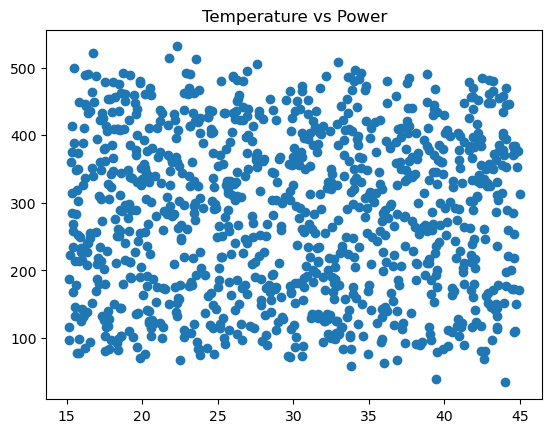

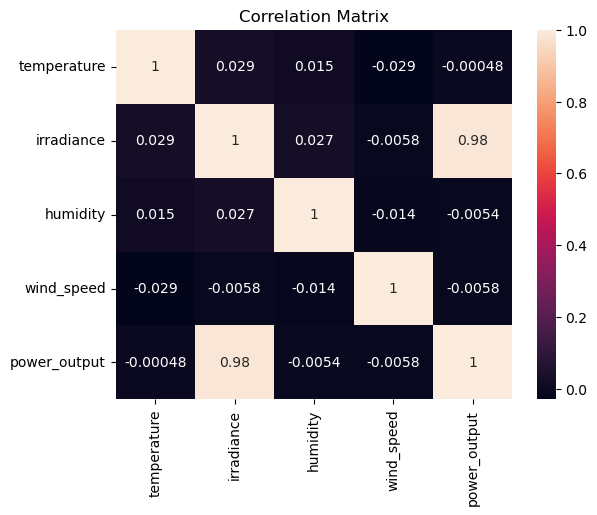

RMSE: 23.10833515718836
R2: 0.9635303767931063


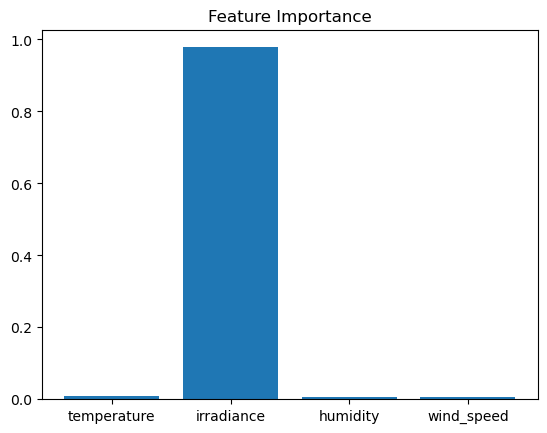

API Error
Optimal Conditions:
   temperature  irradiance  humidity  wind_speed
0    16.578947      1000.0        40           5
Max Output: 488.5440487831166


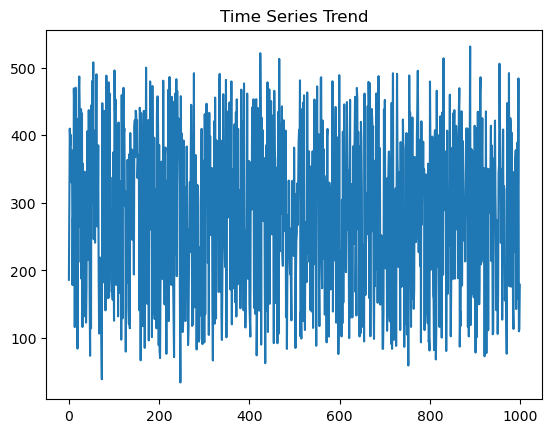

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False

try:
    df = pd.read_csv("solar_data.csv")
except:
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        "temperature": np.random.uniform(15, 45, n),
        "irradiance": np.random.uniform(200, 1000, n),
        "humidity": np.random.uniform(20, 90, n),
        "wind_speed": np.random.uniform(0, 15, n)
    })
    df["power_output"] = (
        0.5 * df["irradiance"]
        - 0.3 * df["temperature"]
        - 0.2 * df["humidity"]
        + 0.1 * df["wind_speed"]
        + np.random.normal(0, 20, n)
    )

df.columns = df.columns.str.lower()
df = df.dropna()

plt.figure()
plt.scatter(df["irradiance"], df["power_output"])
plt.xlabel("Irradiance")
plt.ylabel("Power Output")
plt.title("Irradiance vs Power")
plt.show()

plt.figure()
plt.scatter(df["temperature"], df["power_output"])
plt.title("Temperature vs Power")
plt.show()

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

features = ["temperature", "irradiance", "humidity", "wind_speed"]
X = df[features]
y = df["power_output"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

if XGB_AVAILABLE:
    xgb_model = XGBRegressor()
    xgb_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))

if XGB_AVAILABLE:
    xgb_pred = xgb_model.predict(X_test)
    print("RMSE (XGB):", np.sqrt(mean_squared_error(y_test, xgb_pred)))
    print("R2 (XGB):", r2_score(y_test, xgb_pred))

importance = rf_model.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

API_KEY = "YOUR_API_KEY"
CITY = "Kolkata"

try:
    url = f"http://api.openweathermap.org/data/2.5/weather?q={CITY}&appid={API_KEY}&units=metric"
    weather = requests.get(url).json()

    temp = weather["main"]["temp"]
    humidity = weather["main"]["humidity"]
    wind = weather["wind"]["speed"]

    weather_type = weather["weather"][0]["main"]
    irradiance = 800 if weather_type == "Clear" else 400

    live_input = pd.DataFrame([[temp, irradiance, humidity, wind]], columns=features)
    prediction = rf_model.predict(live_input)[0]

    print("Weather:", weather_type)
    print("Predicted Power:", prediction)

except:
    print("API Error")

temp_range = np.linspace(15, 45, 20)
irr_range = np.linspace(200, 1000, 20)

best_output = -np.inf
best_config = None

for t in temp_range:
    for ir in irr_range:
        sample = pd.DataFrame([[t, ir, 40, 5]], columns=features)
        pred = rf_model.predict(sample)[0]
        if pred > best_output:
            best_output = pred
            best_config = sample

print("Optimal Conditions:")
print(best_config)
print("Max Output:", best_output)

df["time_index"] = range(len(df))

plt.figure()
plt.plot(df["time_index"], df["power_output"])
plt.title("Time Series Trend")
plt.show()